# 03 · Pronóstico de demanda jerárquica

## Enunciado

*Contexto del Problema*:

Una gran cadena minorista necesita optimizar su gestión de inventario para miles de productos en múltiples tiendas y estados. La precisión en la previsión de la demanda es crucial para minimizar el exceso de existencias y las roturas de stock (out-of-stock), lo cual tiene un impacto directo en la rentabilidad del producto.

|Nivel|Descripción de la Agregación|Serie de Tiempo|# de Series|
| :------- | :------: | -------: | :------- |
|1|Total Ventas (Global)|Suma de todas las ventas en EE. UU.|1|
|2|Por Estado|"Ventas totales en CA| TX| WI."|3|
|3|Por Categoría|"Ventas totales de Foods| Hobbies| Household."|3|
|4|Por Estado y Categoría|"Ventas de Foods en CA| Foods en TX| etc."|9|
|5|Por Tienda|Ventas totales en cada una de las 10 tiendas.|10|
|6|Por Departamento|Ventas totales en cada uno de los 7 departamentos.|7|
|7|Por Estado y Departamento|"Ventas del Dpto. X en CA| Dpto. Y en TX| etc."|21|
|8|Por Tienda y Categoría|"Ventas de Foods en Tienda 1| Hobbies en Tienda 2| etc."|30|
|9|Por Producto|Ventas totales del Producto A en todos los estados.|"3.049"|
|10|Por Tienda y Departamento|"Ventas del Dpto. X en Tienda 1| Dpto. Y en Tienda 2| etc."|70|
|11|Por Producto y Categoría|(Agregación implícita por producto)|"3.049"|
|12|Nivel Base (Más granular)|Ventas diarias del Producto i en la Tienda j.|"30.490"|

## Objetivo:
El objetivo es construir un modelo de Machine Learning para la previsión de la demanda a nivel de producto-tienda-día, y abordar los desafíos inherentes a la alta variabilidad y la estructura jerárquica de los datos.

Además utilizando el framework de *Conformal prediction* calcular la incertidumbre lo(s) modelo(s) para saber cuándo el modelo tiene una mayor incertidumbre.

## Setup

In [9]:
%load_ext autoreload
%autoreload 2

import pandas as pd

pd.set_option("display.max_columns", 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

from process.demanda import crear_features, entrenar_modelo_tiendas, preparar_demanda_tiendas

df = preparar_demanda_tiendas()
print("Shape:", df.shape)
df.head()

/home/daniel/Documents/process/src/process/demanda/prep.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg = df.groupby("store_id", observed=True)[d_cols].sum().reset_index()


Shape: (19130, 7)


,store_id,d,ventas,date,wday,month,event_name_1
0,CA_1,d_1,4337,2011-01-29,1,1,NaN
1,CA_1,d_2,4155,2011-01-30,2,1,NaN
2,CA_1,d_3,2816,2011-01-31,3,1,NaN
3,CA_1,d_4,3051,2011-02-01,4,2,NaN
4,CA_1,d_5,2630,2011-02-02,5,2,NaN


## 1. Feature Engineering

Creamos variables temporales (lags, promedios móviles) y de calendario (día de la semana, eventos).

In [11]:
df_feat = crear_features(df)
df_feat = df_feat.dropna()
df_feat.tail()

,store_id,d,ventas,date,wday,month,event_name_1,dia_semana,es_fin_semana,hay_evento,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
1505,WI_3,d_1844,4499,2016-02-15,3,2,PresidentsDay,0,0,1,5032.0,3468.0,3938.0,3033.0,4458.142857,3804.035714
1506,WI_3,d_1846,3362,2016-02-17,5,2,LentWeek2,2,0,1,3573.0,3833.0,4153.0,2823.0,4583.285714,3874.107143
1507,WI_3,d_1875,3412,2016-03-17,6,3,StPatricksDay,3,0,1,3095.0,3350.0,4390.0,2960.0,4106.142857,3945.571429
1508,WI_3,d_1882,2918,2016-03-24,6,3,Purim End,3,0,1,2627.0,3412.0,3350.0,3095.0,3557.571429,3927.285714
1509,WI_3,d_1885,4051,2016-03-27,2,3,Easter,6,1,1,4869.0,4316.0,4976.0,4412.0,3594.571429,3962.285714


## 2. Modelado Jerárquico con Incertidumbre

Entrenamos un modelo LightGBM para predecir las ventas a nivel de tienda. Como es crítico visualizar la incertidumbre del pronóstico (por la volatilidad del retail), implementamos Conformal Prediction usando MAPIE (EnbPI para series temporales). Esto nos da intervalos de predicción con garantías estadísticas válidas.

In [12]:
res = entrenar_modelo_tiendas(df_feat, horizonte=28)
print(f"MAE (Test 28 días): {res['mae']:.2f}")
print(f"MAPE (Test 28 días): {res['mape']:.2%}")

MAE (Test 28 días): 513.71
MAPE (Test 28 días): 7316709229253760000.00%


## 3. Visualización del Pronóstico

Graficamos las predicciones junto con los intervalos de confianza del 90% para un par de tiendas de ejemplo.

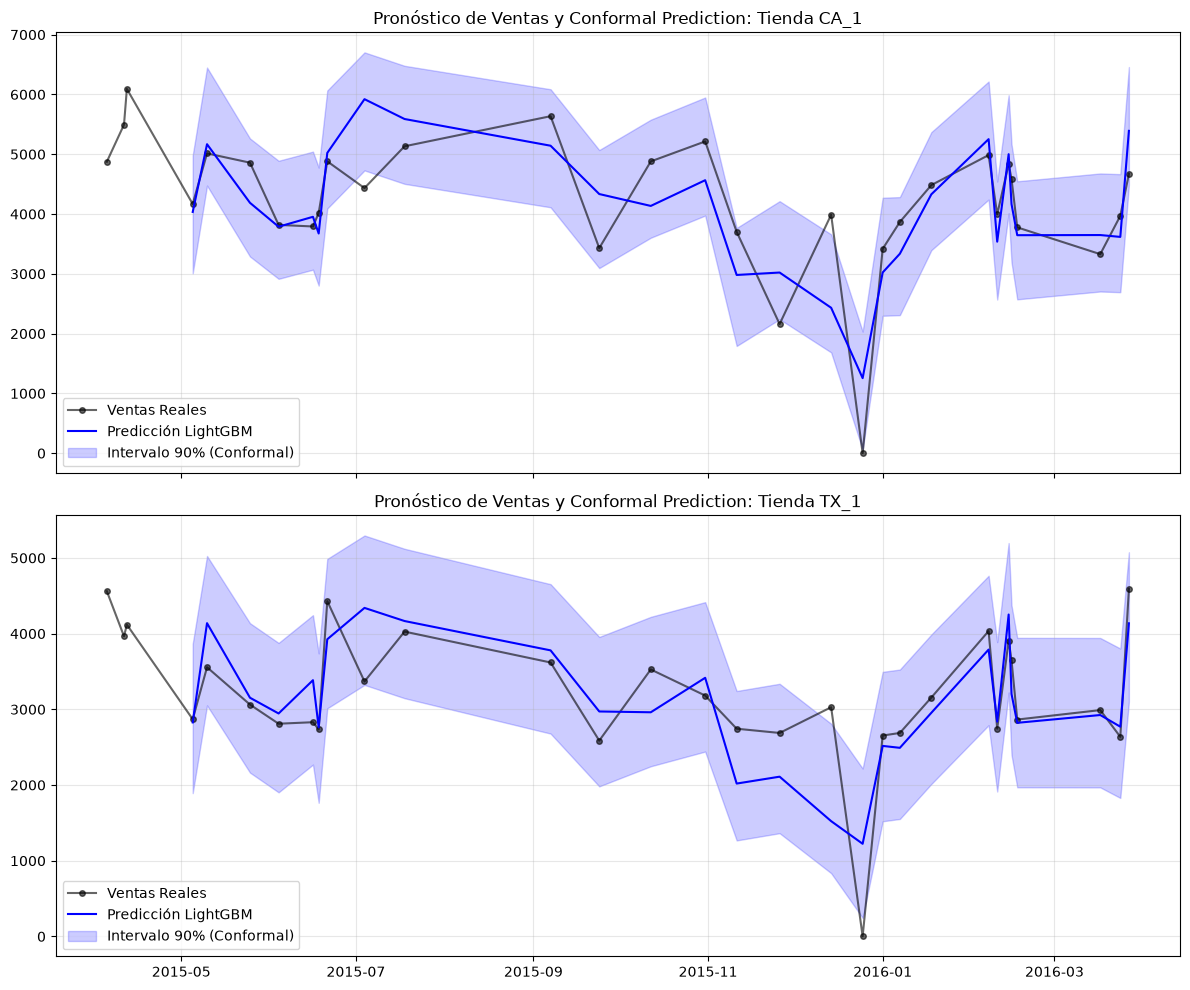

In [13]:
tiendas_ejemplo = ["CA_1", "TX_1"]
fig, axes = plt.subplots(
    len(tiendas_ejemplo), 1, figsize=(12, 5 * len(tiendas_ejemplo)), sharex=True
)

for ax, tienda in zip(axes, tiendas_ejemplo, strict=False):
    plot_df = res["resultados"][res["resultados"]["store_id"] == tienda]
    # Mostrar también algunos días reales de contexto
    context_df = df_feat[
        (df_feat["store_id"] == tienda)
        & (df_feat["date"] >= plot_df["date"].min() - pd.Timedelta(days=30))
    ]

    ax.plot(
        context_df["date"],
        context_df["ventas"],
        label="Ventas Reales",
        marker="o",
        markersize=4,
        color="black",
        alpha=0.6,
    )
    ax.plot(plot_df["date"], plot_df["prediccion"], label="Predicción LightGBM", color="blue")
    ax.fill_between(
        plot_df["date"],
        plot_df["limite_inferior"],
        plot_df["limite_superior"],
        color="blue",
        alpha=0.2,
        label="Intervalo 90% (Conformal)",
    )
    ax.set_title(f"Pronóstico de Ventas y Conformal Prediction: Tienda {tienda}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusión
El modelo LightGBM captura la tendencia y estacionalidad a nivel de tienda. MAPIE nos provee una banda de incertidumbre rigurosa (zona sombreada) donde el sistema garantiza probabilísticamente que caerá la demanda futura real. Esta banda es fundamental para optimizar los niveles de inventario de seguridad y evitar quiebres de stock sin incurrir en excesos de inventario.